# IFN680 Project 5 - main_report: Task 3 Evaluation & Comparative Analysis

**Group 4** — Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook reproduces **all Task 3 results and plots**. It **does not train**:
it loads the two saved models (`LLMForward.pth`, `LLMReverse.pth`) and the shared
held-out test set (`project5_testset.pkl`), then compares the Forward and Reverse
paradigms across operations, digit positions, and carry/borrow cases.
Run it top-to-bottom.

In [1]:
# Core libraries (same stack as the Week 7 workshop)
import torch
from torch import nn
from torch.nn import functional as F
import random, math, re, time, pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Reproducibility
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device: cuda


In [2]:
# --- Tokenizer -------------------------------------------------------------
# Vocabulary is the workshop's plus a single '-' token, which serves BOTH as the
# subtraction operator ("50-73=") and as the negative sign in a result ("-23").
# Ids: 0-9 digits, 10 '+', 11 '-', 12 '=', 13 [PAD], 14 [EOS].
pad_token = "[PAD]"
eos_token = "[EOS]"

class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"
    def clean(self, text):
        return re.sub(self.pattern, "", text)
    def pre_tokenization(self, text):
        return [c for c in text]
    def encode(self, text):
        return [self.token_to_id[c] for c in self.pre_tokenization(self.clean(text))]
    def decode(self, token_list):
        return "".join([self.id_to_token[i] for i in token_list])

tokenizer = character_level_tokenizer()
ntokens = tokenizer.ntokens
print("ntokens:", ntokens, "| vocab:", tokenizer.vocab)

ntokens: 15 | vocab: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']


In [3]:
# --- Data generation: a (+|-) b = c ---------------------------------------
# Operands are non-negative, at most `number_digits` digits. Subtraction may be
# negative (b > a), rendered by str() with a leading '-'.
def sample_datapoint(number_digits=3, operation=None):
    if operation is None:
        operation = random.choice(["+", "-"])
    hi = 10 ** number_digits
    a_int = random.randint(0, hi - 1)
    b_int = random.randint(0, hi - 1)
    result = a_int + b_int if operation == "+" else a_int - b_int
    return f"{a_int}{operation}{b_int}=", str(result)

def build_dataset(train_size, val_size, test_size, number_digits=3, seed=SEED):
    """Unique, non-overlapping splits with a balanced 50/50 add/sub mix."""
    rng = random.Random(seed)
    total = train_size + val_size + test_size
    per_op = total // 2 + 1
    def unique_for(op, n):
        seen, out, hi = set(), [], 10 ** number_digits
        while len(out) < n:
            a, b = rng.randint(0, hi - 1), rng.randint(0, hi - 1)
            prompt = f"{a}{op}{b}="
            if prompt in seen:
                continue
            seen.add(prompt)
            result = a + b if op == "+" else a - b
            out.append((prompt, str(result)))
        return out
    add, sub = unique_for("+", per_op), unique_for("-", per_op)
    mixed = []
    for pa, pb in zip(add, sub):
        mixed += [pa, pb]
    rng.shuffle(mixed)
    return (mixed[:train_size],
            mixed[train_size:train_size + val_size],
            mixed[train_size + val_size:train_size + val_size + test_size])

# --- Reverse-mode transform (literal full-string reversal) ------------------
# "31"->"13", "1998"->"8991", "-123"->"321-" (sign predicted LAST).
def to_reverse(s):   return s[::-1]
def from_reverse(s): return s[::-1]

def parse_answer(answer_str, reverse=False):
    """Decoded answer string -> int (un-reversing first in reverse mode)."""
    s = from_reverse(answer_str) if reverse else answer_str
    neg = s.startswith("-")
    digits = "".join(ch for ch in s if ch.isdigit())
    if digits == "":
        return None
    return -int(digits) if neg else int(digits)

# --- Carry (add) / borrow (sub) structure, units-first ----------------------
def carry_positions(a, b):
    width = max(len(str(a)), len(str(b)), len(str(a + b)))
    sa, sb = str(a).zfill(width), str(b).zfill(width)
    carry, flags = 0, []
    for i in reversed(range(width)):
        flags.append(carry)
        carry = 1 if int(sa[i]) + int(sb[i]) + carry >= 10 else 0
    return flags

def borrow_positions(a, b):
    hi, lo = (a, b) if a >= b else (b, a)
    width = max(len(str(hi)), len(str(lo)))
    sh, sl = str(hi).zfill(width), str(lo).zfill(width)
    borrow, flags = 0, []
    for i in reversed(range(width)):
        top, bot = int(sh[i]) - borrow, int(sl[i])
        flags.append(1 if top < bot else 0)
        borrow = 1 if top < bot else 0
    return flags

def operation_of(prompt):
    return "+" if "+" in prompt else "-"

In [4]:
# --- Positional encoding (sinusoidal, from the workshop) --------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp((torch.arange(0, d_model, 2).float() / d_model) * (-math.log(1e4)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)
    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

In [5]:
# --- Transformer with causal (masked) self-attention ------------------------
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None
    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src, attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True, average_attn_weights=False)
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2); src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2); src = self.norm2(src)
        return src

class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()
    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)
    def _generate_square_subsequent_mask(self, sz):
        return torch.log(torch.tril(torch.ones(sz, sz)))
    def forward(self, src):
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        src = self.input_emb(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output_enc = self.encoder(src, mask=mask)
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps

In [6]:
# REVERSE is toggled per model when evaluating; a module-level default is set here.
REVERSE = False

In [7]:
# --- Autoregressive generation + padding/batching ---------------------------
def generate(model, prompts, new_tokens=6):
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        last = output[-1, :, :]
        token = torch.argmax(last, -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor

def pad(token_list, type_list="prompts"):
    max_length = max(len(x) for x in token_list)
    out = []
    for x in token_list:
        if type_list == "prompts":            # left-pad prompts
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x)
        else:                                  # answers: sequence + EOS + right-pad
            out.append(x + [tokenizer.token_to_id[eos_token]] +
                       [tokenizer.token_to_id[pad_token]] * (max_length - len(x)))
    return out, max_length

# REVERSE controls whether the TARGET answer is reversed before tokenising.
def get_batch(data, i, batch_size):
    j_end = min(i + batch_size, len(data))
    prompts = [tokenizer.encode(data[j][0]) for j in range(i, j_end)]
    padded_prompts, length_prompts = pad(prompts, "prompts")
    answers = [tokenizer.encode(to_reverse(data[j][1]) if REVERSE else data[j][1])
               for j in range(i, j_end)]
    padded_answers, length_answers = pad(answers, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

In [8]:
# --- Token-level accuracy (digit + full-sequence), from the workshop --------
def evaluate(input_data, batch_size=200):
    model.eval()
    correct_digit = total_digit = correct = total = 0.
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            prompts, target_answers, length_prompts, length_answers = get_batch(input_data, i, batch_size)
            prompts = prompts.to(device); target_answers = target_answers.to(device)
            output = generate(model, prompts, length_answers + 1)
            answers_tokens = output[length_prompts:, :]
            target_mask_pad = target_answers != tokenizer.token_to_id[pad_token]
            equality_test = answers_tokens == target_answers
            correct_digit += torch.logical_and(target_mask_pad, equality_test).sum().item()
            total_digit += target_mask_pad.sum().item()
            correct += torch.all(torch.logical_or(~target_mask_pad, equality_test), axis=0).float().sum().item()
            total += target_answers.shape[-1]
    return correct_digit / total_digit, correct / total

# --- Numeric prediction over a dataset (used for Task 3 numeric accuracy) ---
def predict_numeric(input_data, batch_size=200, new_tokens=6):
    """Return (prompts, true_ints, pred_ints). pred is None if unparseable."""
    model.eval()
    prompts_out, trues, preds = [], [], []
    with torch.no_grad():
        for i in range(0, len(input_data), batch_size):
            chunk = input_data[i:i + batch_size]
            enc = [tokenizer.encode(p) for p, _ in chunk]
            padded, Lp = pad(enc, "prompts")
            X = torch.stack([torch.tensor(x) for x in padded], 1).to(device)
            out = generate(model, X, new_tokens)
            gen = out[Lp:, :]
            for b, (p, t) in enumerate(chunk):
                s = tokenizer.decode(gen[:, b].tolist())
                s = s.split(eos_token)[0].replace(pad_token, "")
                prompts_out.append(p); trues.append(int(t))
                preds.append(parse_answer(s, reverse=REVERSE))
    return prompts_out, trues, preds

## Load the shared test set and both trained models

In [9]:
with open("project5_testset.pkl", "rb") as f:
    data_test = pickle.load(f)
print(f"test examples: {len(data_test)} "
      f"(sub fraction {sum('-' in p for p,_ in data_test)/len(data_test):.2f})")
assert len(data_test) >= 10000, "held-out test set must have >= 10k samples"

def load_model(path):
    m = TransformerModel(ntoken=ntokens, ninp=128, nhead=16, nhid=64, nlayers=6).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

forward_model = load_model("LLMForward.pth")
reverse_model = load_model("LLMReverse.pth")
print("loaded LLMForward.pth and LLMReverse.pth")

test examples: 10000 (sub fraction 0.49)


loaded LLMForward.pth and LLMReverse.pth


/tmp/ipykernel_285/25258673.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


## Run predictions for both modes on the same examples

In [10]:
def run(model_, reverse_flag):
    global model, REVERSE
    model, REVERSE = model_, reverse_flag
    return predict_numeric(data_test)

prompts_f, trues, preds_f = run(forward_model, False)
prompts_r, _,     preds_r = run(reverse_model, True)
assert prompts_f == prompts_r  # identical examples & order
prompts = prompts_f
print("done predicting both modes")

done predicting both modes


## Analysis helpers (operation, digit-position, carry/borrow)

In [11]:
def positional_digits(value, width=4):
    return list(str(abs(int(value))).zfill(width))   # thousands..units

def overall_acc(preds):
    return np.mean([p is not None and p == t for t, p in zip(trues, preds)])

def op_acc(preds, op):
    idx = [i for i, pr in enumerate(prompts) if operation_of(pr) == op]
    return np.mean([preds[i] is not None and preds[i] == trues[i] for i in idx]), len(idx)

def position_acc(preds):
    """Per-place accuracy over |value| padded to 4 digits, plus sign accuracy."""
    labels = ["thousands", "hundreds", "tens", "units"]
    pos_correct = {k: 0 for k in labels}; sign_correct = 0; n = len(trues)
    for t, p in zip(trues, preds):
        td = positional_digits(t)
        pd = positional_digits(p) if p is not None else ["x", "x", "x", "x"]
        for k, tc, pc in zip(labels, td, pd):
            pos_correct[k] += (tc == pc)
        sign_correct += (p is not None and (p < 0) == (t < 0))
    acc = {k: pos_correct[k] / n for k in labels}
    acc["sign"] = sign_correct / n
    return acc

In [12]:
def carry_borrow_acc(preds):
    """Accuracy on examples that DO vs DO NOT involve a carry (add) / borrow (sub)."""
    res = {}
    for op, fn in [("+", carry_positions), ("-", borrow_positions)]:
        withc = nowc = withc_ok = nowc_ok = 0
        for i, pr in enumerate(prompts):
            if operation_of(pr) != op:
                continue
            a, b = (int(x) for x in pr[:-1].split(op))
            flags = fn(a, b)
            ok = preds[i] is not None and preds[i] == trues[i]
            if sum(flags) > 0:
                withc += 1; withc_ok += ok
            else:
                nowc += 1; nowc_ok += ok
        name = "carry" if op == "+" else "borrow"
        res[name] = {f"with_{name}": (withc_ok / withc if withc else float("nan"), withc),
                     f"no_{name}":   (nowc_ok / nowc if nowc else float("nan"), nowc)}
    return res

## Results — overall and per-operation accuracy

In [13]:
print(f"{'mode':>8} | {'overall':>8} | {'addition':>9} | {'subtraction':>12}")
for name, preds in [("Forward", preds_f), ("Reverse", preds_r)]:
    o = overall_acc(preds); add, _ = op_acc(preds, "+"); sub, _ = op_acc(preds, "-")
    print(f"{name:>8} | {o:8.3f} | {add:9.3f} | {sub:12.3f}")
    assert o >= 0.0

    mode |  overall |  addition |  subtraction
 Forward |    0.999 |     1.000 |        0.999
 Reverse |    0.996 |     0.995 |        0.997


## Results — per digit-position and sign accuracy

In [14]:
acc_f, acc_r = position_acc(preds_f), position_acc(preds_r)
labels = ["thousands", "hundreds", "tens", "units", "sign"]
print(f"{'position':>10} | {'Forward':>8} | {'Reverse':>8}")
for k in labels:
    print(f"{k:>10} | {acc_f[k]:8.3f} | {acc_r[k]:8.3f}")

  position |  Forward |  Reverse
 thousands |    1.000 |    1.000
  hundreds |    1.000 |    1.000
      tens |    1.000 |    0.996
     units |    0.999 |    0.999
      sign |    1.000 |    1.000


## Results — carry (addition) and borrow (subtraction) cases

In [15]:
cb_f, cb_r = carry_borrow_acc(preds_f), carry_borrow_acc(preds_r)
for grp in ("carry", "borrow"):
    print(f"\n{grp.upper()} (Forward / Reverse):")
    for key in cb_f[grp]:
        (fv, fn_), (rv, rn) = cb_f[grp][key], cb_r[grp][key]
        print(f"  {key:>12}: Fwd {fv:.3f} (n={fn_})   Rev {rv:.3f} (n={rn})")


CARRY (Forward / Reverse):
    with_carry: Fwd 1.000 (n=4226)   Rev 0.996 (n=4226)
      no_carry: Fwd 1.000 (n=850)   Rev 0.989 (n=850)

BORROW (Forward / Reverse):
   with_borrow: Fwd 0.998 (n=3322)   Rev 0.997 (n=3322)
     no_borrow: Fwd 0.999 (n=1602)   Rev 0.996 (n=1602)


## Figures for the report

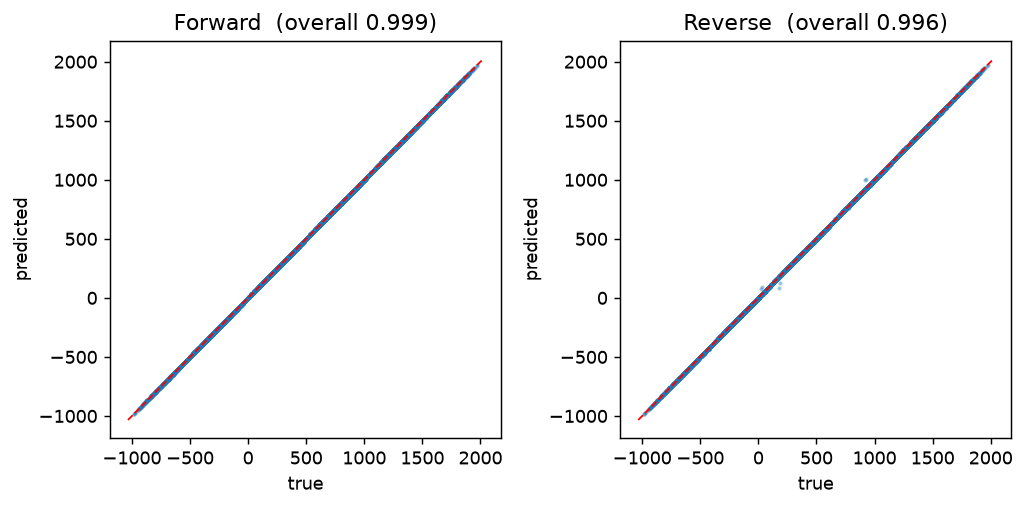

In [16]:
# Figure 1: predicted vs true scatter (both modes)
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=130)
for ax, name, preds in zip(axes, ["Forward", "Reverse"], [preds_f, preds_r]):
    tp = [(t, p) for t, p in zip(trues, preds) if p is not None]
    tt, pp = zip(*tp)
    ax.scatter(tt, pp, s=2, alpha=0.3, c="tab:blue")
    lim = [min(trues) - 50, max(trues) + 50]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_title(f"{name}  (overall {overall_acc(preds):.3f})")
    ax.set_xlabel("true"); ax.set_ylabel("predicted")
plt.tight_layout(); plt.savefig("fig_scatter.png", bbox_inches="tight"); plt.show()

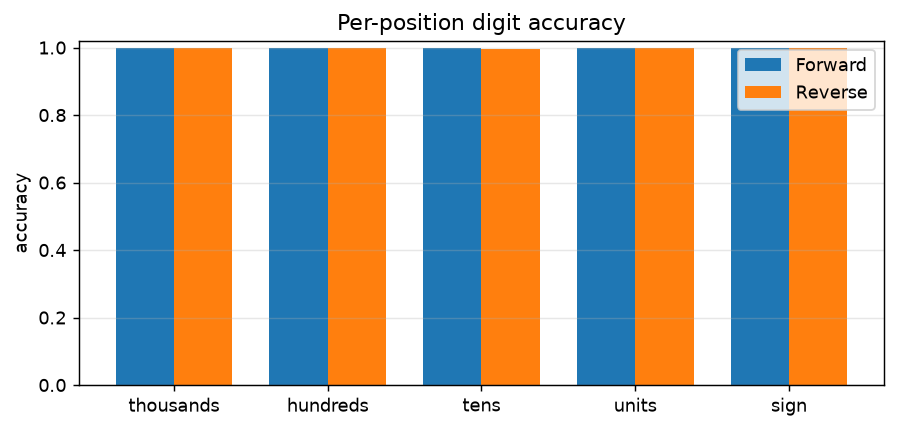

In [17]:
# Figure 2: per-digit-position accuracy, Forward vs Reverse
labels = ["thousands", "hundreds", "tens", "units", "sign"]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 3.4), dpi=130)
ax.bar(x - w/2, [acc_f[k] for k in labels], w, label="Forward", color="tab:blue")
ax.bar(x + w/2, [acc_r[k] for k in labels], w, label="Reverse", color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.02)
ax.set_ylabel("accuracy"); ax.legend(); ax.grid(alpha=0.3, axis="y")
ax.set_title("Per-position digit accuracy")
plt.tight_layout(); plt.savefig("fig_positions.png", bbox_inches="tight"); plt.show()

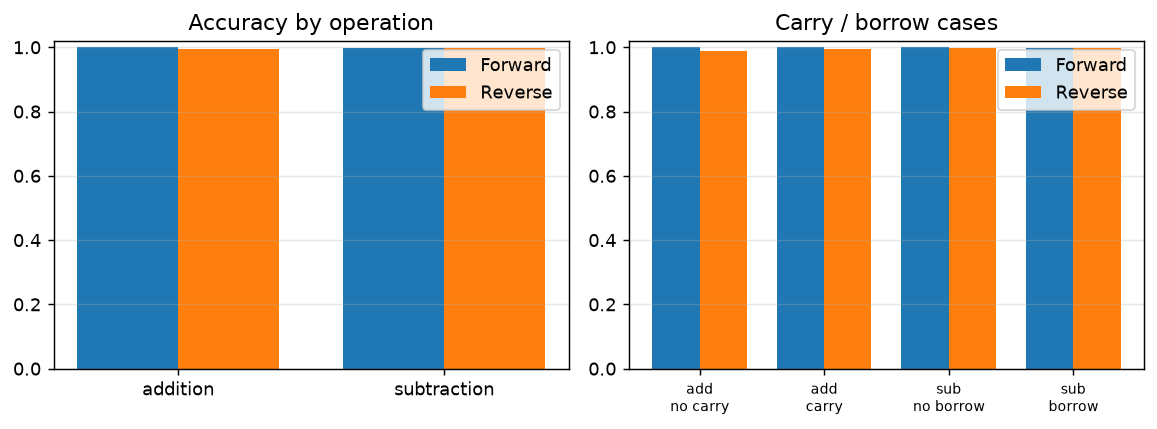

In [18]:
# Figure 3: operation x mode, and carry/borrow x mode
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), dpi=130)
# operation
ops = ["addition", "subtraction"]
fa = [op_acc(preds_f, "+")[0], op_acc(preds_f, "-")[0]]
ra = [op_acc(preds_r, "+")[0], op_acc(preds_r, "-")[0]]
x = np.arange(2); w = 0.38
axes[0].bar(x - w/2, fa, w, label="Forward", color="tab:blue")
axes[0].bar(x + w/2, ra, w, label="Reverse", color="tab:orange")
axes[0].set_xticks(x); axes[0].set_xticklabels(ops); axes[0].set_ylim(0, 1.02)
axes[0].set_title("Accuracy by operation"); axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")
# carry/borrow
cats = ["add\nno carry", "add\ncarry", "sub\nno borrow", "sub\nborrow"]
def val(cb, grp, key): return cb[grp][key][0]
fvals = [val(cb_f,"carry","no_carry"), val(cb_f,"carry","with_carry"),
         val(cb_f,"borrow","no_borrow"), val(cb_f,"borrow","with_borrow")]
rvals = [val(cb_r,"carry","no_carry"), val(cb_r,"carry","with_carry"),
         val(cb_r,"borrow","no_borrow"), val(cb_r,"borrow","with_borrow")]
x = np.arange(4)
axes[1].bar(x - w/2, fvals, w, label="Forward", color="tab:blue")
axes[1].bar(x + w/2, rvals, w, label="Reverse", color="tab:orange")
axes[1].set_xticks(x); axes[1].set_xticklabels(cats, fontsize=8); axes[1].set_ylim(0, 1.02)
axes[1].set_title("Carry / borrow cases"); axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("fig_carry_borrow.png", bbox_inches="tight"); plt.show()

## Summary table (numbers used in the report)

In [19]:
summary = {
    "overall":   {"Forward": float(overall_acc(preds_f)), "Reverse": float(overall_acc(preds_r))},
    "addition":  {"Forward": float(op_acc(preds_f,"+")[0]), "Reverse": float(op_acc(preds_r,"+")[0])},
    "subtraction":{"Forward": float(op_acc(preds_f,"-")[0]), "Reverse": float(op_acc(preds_r,"-")[0])},
    "positions": {"Forward": acc_f, "Reverse": acc_r},
    "carry_borrow": {"Forward": cb_f, "Reverse": cb_r},
}
import json
print(json.dumps(summary, indent=1, default=lambda o: round(float(o),4)))

{
 "overall": {
  "Forward": 0.9993,
  "Reverse": 0.9956
 },
 "addition": {
  "Forward": 1.0,
  "Reverse": 0.9946808510638298
 },
 "subtraction": {
  "Forward": 0.9985783915515841,
  "Reverse": 0.9965475223395613
 },
 "positions": {
  "Forward": {
   "thousands": 1.0,
   "hundreds": 1.0,
   "tens": 1.0,
   "units": 0.9993,
   "sign": 1.0
  },
  "Reverse": {
   "thousands": 0.9999,
   "hundreds": 0.9995,
   "tens": 0.9959,
   "units": 0.9991,
   "sign": 1.0
  }
 },
 "carry_borrow": {
  "Forward": {
   "carry": {
    "with_carry": [
     1.0,
     4226
    ],
    "no_carry": [
     1.0,
     850
    ]
   },
   "borrow": {
    "with_borrow": [
     0.9981938591210114,
     3322
    ],
    "no_borrow": [
     0.9993757802746567,
     1602
    ]
   }
  },
  "Reverse": {
   "carry": {
    "with_carry": [
     0.995740653099858,
     4226
    ],
    "no_carry": [
     0.9894117647058823,
     850
    ]
   },
   "borrow": {
    "with_borrow": [
     0.9966887417218543,
     3322
    ],
    "no